# Analysis of the spatial myofiber niches in the integrated 480+5000 genes fiber dataset
The spatial myofiber niches were determined in the 5000 genes dataset in `spatial_clustering_final.ipynb` (myofiber niche clustering in the 480 genes dataset had a low stability.) The analysis in this script is done using the integrated fiber dataset, so gene expression in the 480 and 5000 genes panels in matching fibers can be analysed across the spatial fiber niches.

In [1]:
import numpy as np
import anndata as ad
import scanpy as sc
import squidpy as sq
from pathlib import Path
import matplotlib.pyplot as plt
import os
import pandas as pd
import cellcharter as cc
import matplotlib.gridspec as gridspec

/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_tex

In [2]:
cd ../../data/IBM

/exports/archive/hg-groep-spitali/Students/Caro/data/IBM


/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
# load integrated fiber dataset
adata = sc.read_h5ad('integrated_480_5000/adata_integrated_480_5000_fibers_sizenorm_unfiltered.h5ad')
adata

AnnData object with n_obs × n_vars = 8967 × 5850
    obs: 'cell_ID', 'fov_labels', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'CD4_in_neighborhood_200_480', 'CD4_in_neighborhood_200_5000', 'CD4_in_neighborhood_200_mean', 'B_cells_in_neighborhood_200_480', 'B_cells_in_neighborhood_200_5000', 'B_cells_in_neighborhood_200_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_coun

In [4]:
adata.obs['cell_type_annotation_fiber_subtypes'].value_counts()

cell_type_annotation_fiber_subtypes
Myofibers type 1                 6700
Myofibers type 2x                1146
Myofibers type 2a                 559
Damaged myofibers type 2          295
Regenerative myofibers type 2     264
Low quality                         3
Myonuclei type 2                    0
Myonuclei type 1                    0
CD8 T-cells                         0
B-cells                             0
CD4 T-cells                         0
FAPs/Collagen                       0
Satellite cells                     0
Endothelial cells                   0
Pericytes                           0
Name: count, dtype: int64

There are three myofibers in this dataset that were annotated 'low quality' in 480 genes dataset fibertype subclustering. The fibers that were annotated 'low quality' in the 5000 genes dataset (these will be mostly the same, but slightly different due to different clustering results) were already deleted before defining spatial fiber niches. I will also remove these three low quality (by 480 annotation) fibers before further analysis. Mainly so 'low quality' does not show up in plots (only 3 fibers anyways).

This leaves 8967 - 8964 (integrated) fibers.

In [5]:
adata = adata[adata.obs['cell_type_annotation_fiber_subtypes'] != 'Low quality']
adata

View of AnnData object with n_obs × n_vars = 8964 × 5850
    obs: 'cell_ID', 'fov_labels', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'CD4_in_neighborhood_200_480', 'CD4_in_neighborhood_200_5000', 'CD4_in_neighborhood_200_mean', 'B_cells_in_neighborhood_200_480', 'B_cells_in_neighborhood_200_5000', 'B_cells_in_neighborhood_200_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'm

## Plot niche composition barplots

/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


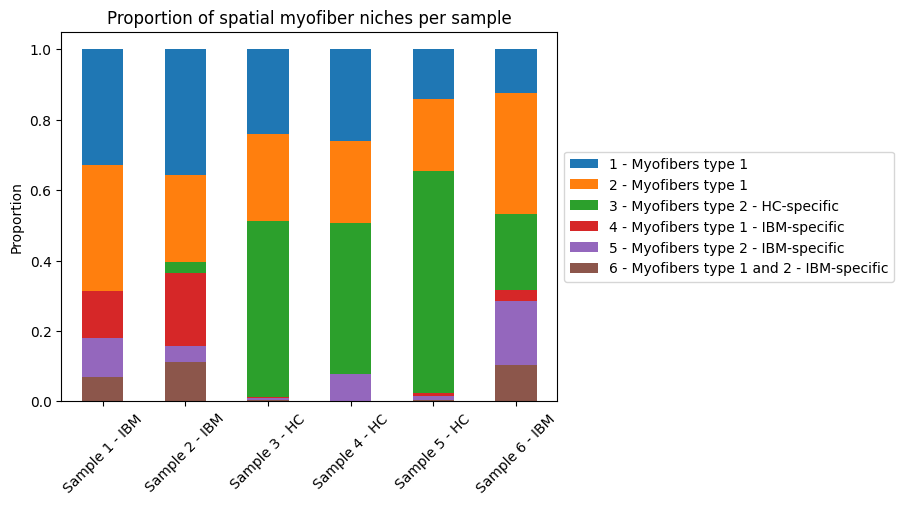

In [31]:
cc.pl.proportion(adata, group_key='sample_condition', label_key='spatial_niches_fibers', 
xlabel='', ylabel='Proportion', title='Proportion of spatial myofiber niches per sample',
save='../../output/spatial_niches/fiber_niches_per_sample.svg')

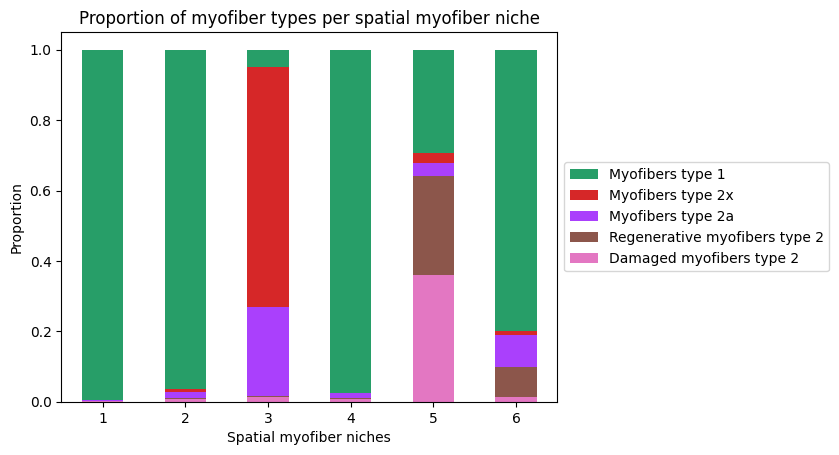

In [32]:
cc.pl.proportion(adata, group_key='spatial_niches_fibers_number', label_key='cell_type_annotation_fiber_subtypes',
title='Proportion of myofiber types per spatial myofiber niche', xlabel='Spatial myofiber niches', ylabel='Proportion',
rotation_xlabel=0, save='../../output/spatial_niches/fibertypes_per_fiber_niche.svg')

## Plot mean CD8 counts in myofiber neighborhoods per niche

/tmp/ipykernel_1405209/3645880789.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data,


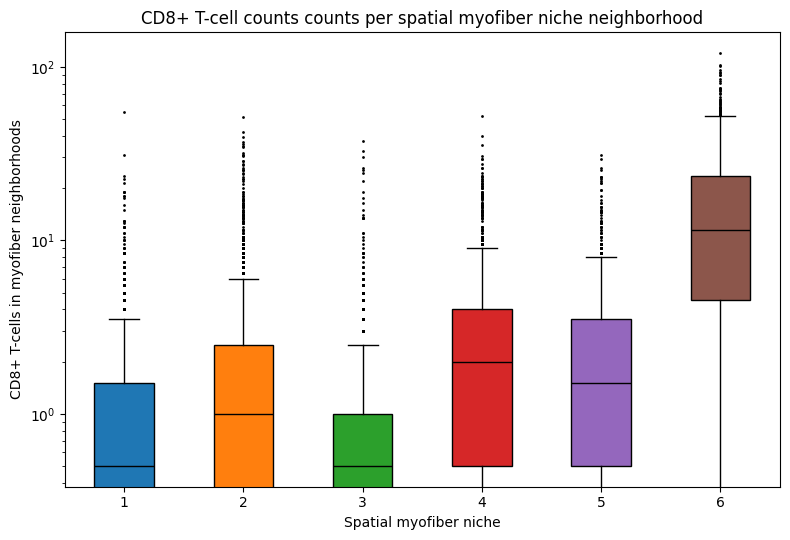

In [ ]:
niche_colors = dict(zip(
    adata.obs['spatial_niches_fibers_number'].cat.categories,
    adata.uns['spatial_niches_fibers_colors']
))

niches = adata.obs['spatial_niches_fibers_number'].cat.categories

data = [
    adata.obs.loc[adata.obs['spatial_niches_fibers_number'] == niche, 'CD8_in_neighborhood_200_mean'].dropna().values
    for niche in niches
]

fig, ax = plt.subplots(figsize=(8, 5.5))

bp = ax.boxplot(data, 
                labels=niches, 
                patch_artist=True, 
                flierprops = dict(marker='o', markersize=2, markerfacecolor='black', markeredgewidth=0))

for patch, niche in zip(bp['boxes'], niches):
    patch.set_facecolor(niche_colors[niche])

plt.setp(bp['medians'], color='black')    

ax.set_yscale('log')
ax.set_xlabel('Spatial myofiber niche')
ax.set_ylabel('CD8+ T-cells in myofiber neighborhoods')
ax.set_title('CD8+ T-cell counts counts per spatial myofiber niche neighborhood')
plt.tight_layout()
plt.savefig('../.../output/spatial_niches/CD8_per_fiber_niche.svg')
plt.show()

### Plot mean CD8 counts per myofiber subtype

/tmp/ipykernel_3192201/1771571299.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data,


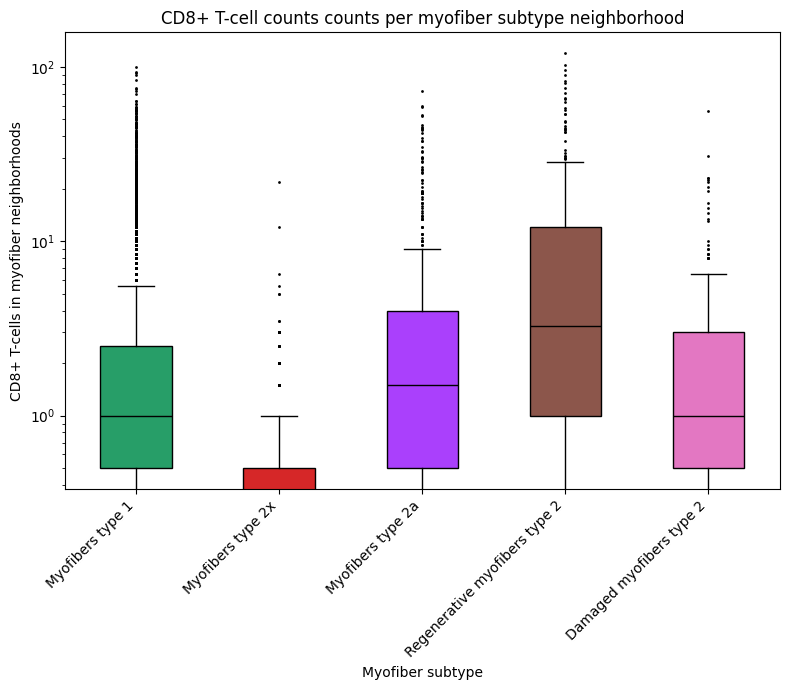

In [ ]:
niche_colors = dict(zip(
    adata.obs['cell_type_annotation_fiber_subtypes'].cat.categories,
    adata.uns['cell_type_annotation_fiber_subtypes_colors']
))

niches = adata.obs['cell_type_annotation_fiber_subtypes'].cat.categories

data = [
    adata.obs.loc[adata.obs['cell_type_annotation_fiber_subtypes'] == niche, 'CD8_in_neighborhood_200_mean'].dropna().values
    for niche in niches
]

fig, ax = plt.subplots(figsize=(8, 7))

bp = ax.boxplot(data, 
                labels=niches, 
                patch_artist=True, 
                flierprops = dict(marker='o', markersize=2, markerfacecolor='black', markeredgewidth=0))

for patch, niche in zip(bp['boxes'], niches):
    patch.set_facecolor(niche_colors[niche])

plt.setp(bp['medians'], color='black')    

ax.set_yscale('log')
ax.set_xlabel('Myofiber subtype')
plt.xticks(rotation=45, ha='right')
ax.set_ylabel('CD8+ T-cells in myofiber neighborhoods')
ax.set_title('CD8+ T-cell counts counts per myofiber subtype neighborhood')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3008350/3669355734.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data,


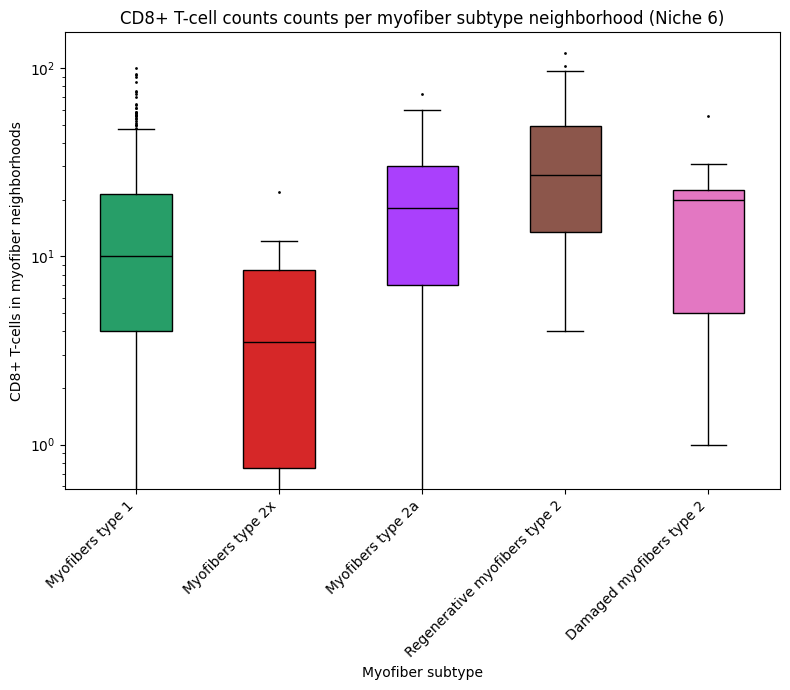

In [ ]:
# CD8 per myofiber type (only for fibers in niche 6)
adata_n6 = adata[adata.obs['spatial_niches_fibers_number'] == '6'].copy()

niche_colors = dict(zip(
    adata_n6.obs['cell_type_annotation_fiber_subtypes'].cat.categories,
    adata_n6.uns['cell_type_annotation_fiber_subtypes_colors']
))

niches = adata_n6.obs['cell_type_annotation_fiber_subtypes'].cat.categories

data = [
    adata_n6.obs.loc[adata_n6.obs['cell_type_annotation_fiber_subtypes'] == niche, 'CD8_in_neighborhood_200_mean'].dropna().values
    for niche in niches
]

fig, ax = plt.subplots(figsize=(8, 7))

bp = ax.boxplot(data, 
                labels=niches, 
                patch_artist=True, 
                flierprops = dict(marker='o', markersize=2, markerfacecolor='black', markeredgewidth=0))

for patch, niche in zip(bp['boxes'], niches):
    patch.set_facecolor(niche_colors[niche])

plt.setp(bp['medians'], color='black')    

ax.set_yscale('log')
ax.set_xlabel('Myofiber subtype')
plt.xticks(rotation=45, ha='right')
ax.set_ylabel('CD8+ T-cells in myofiber neighborhoods')
ax.set_title('CD8+ T-cell counts counts per myofiber subtype neighborhood (Niche 6)')
plt.tight_layout()
plt.show()

## DEG analysis across spatial fiber niches

/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


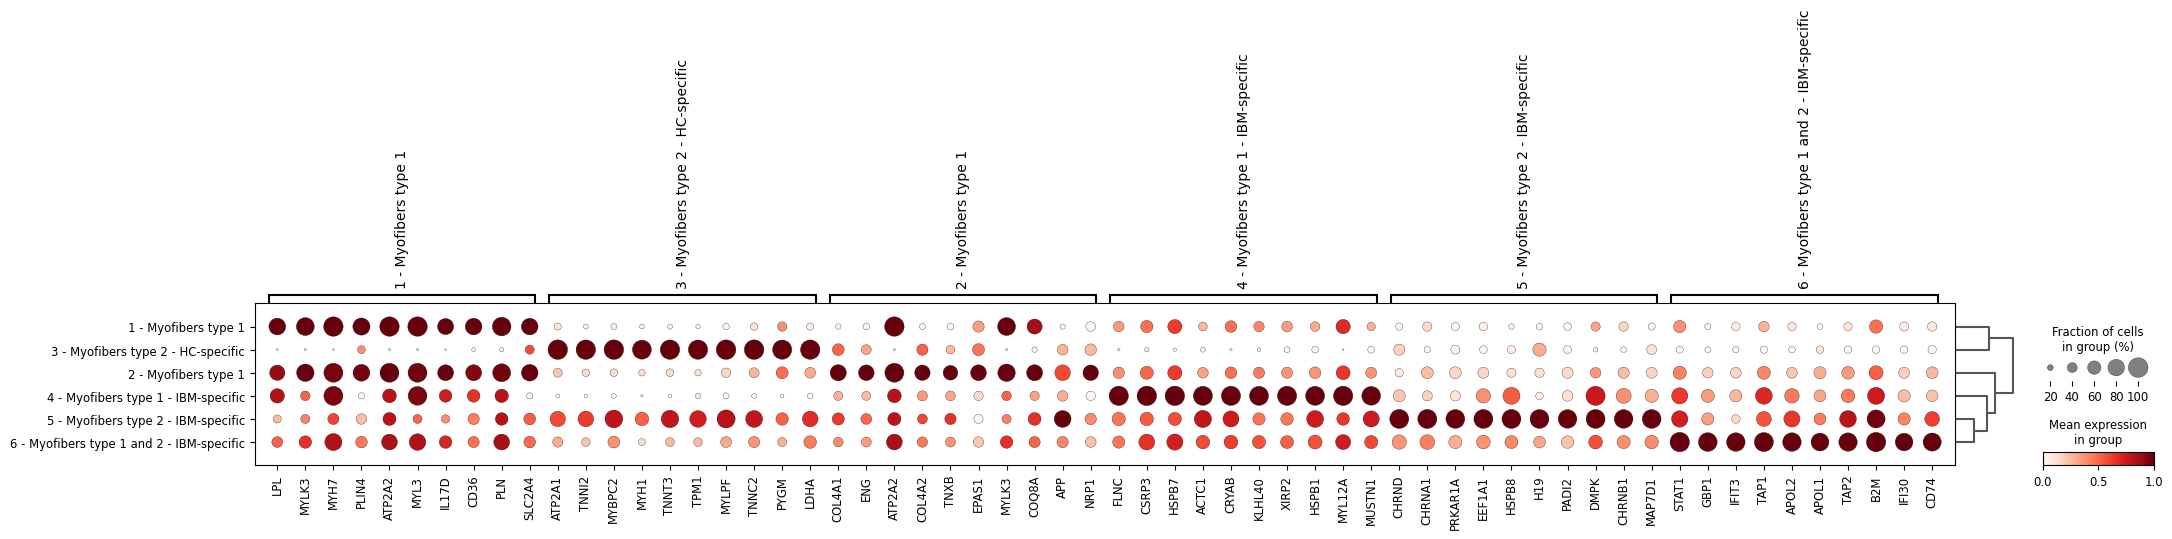

In [6]:
sc.tl.rank_genes_groups(
    adata, groupby="spatial_niches_fibers", method="wilcoxon", key_added="deg_fiber_niches", layer="size_normalized_log", use_raw=False,
)

sc.tl.dendrogram(adata, groupby="spatial_niches_fibers")

sc.pl.rank_genes_groups_dotplot(
    adata, groupby="spatial_niches_fibers", standard_scale="var", n_genes=10, key="deg_fiber_niches")

In [8]:
adata.obs['spatial_niches_fibers'].value_counts()

spatial_niches_fibers
2 - Myofibers type 1                         2458
1 - Myofibers type 1                         2433
3 - Myofibers type 2 - HC-specific           1609
4 - Myofibers type 1 - IBM-specific          1089
6 - Myofibers type 1 and 2 - IBM-specific     723
5 - Myofibers type 2 - IBM-specific           655
Name: count, dtype: int64

In [7]:
deg_df = sc.get.rank_genes_groups_df(adata, group=None, key="deg_fiber_niches", pval_cutoff=0.05)

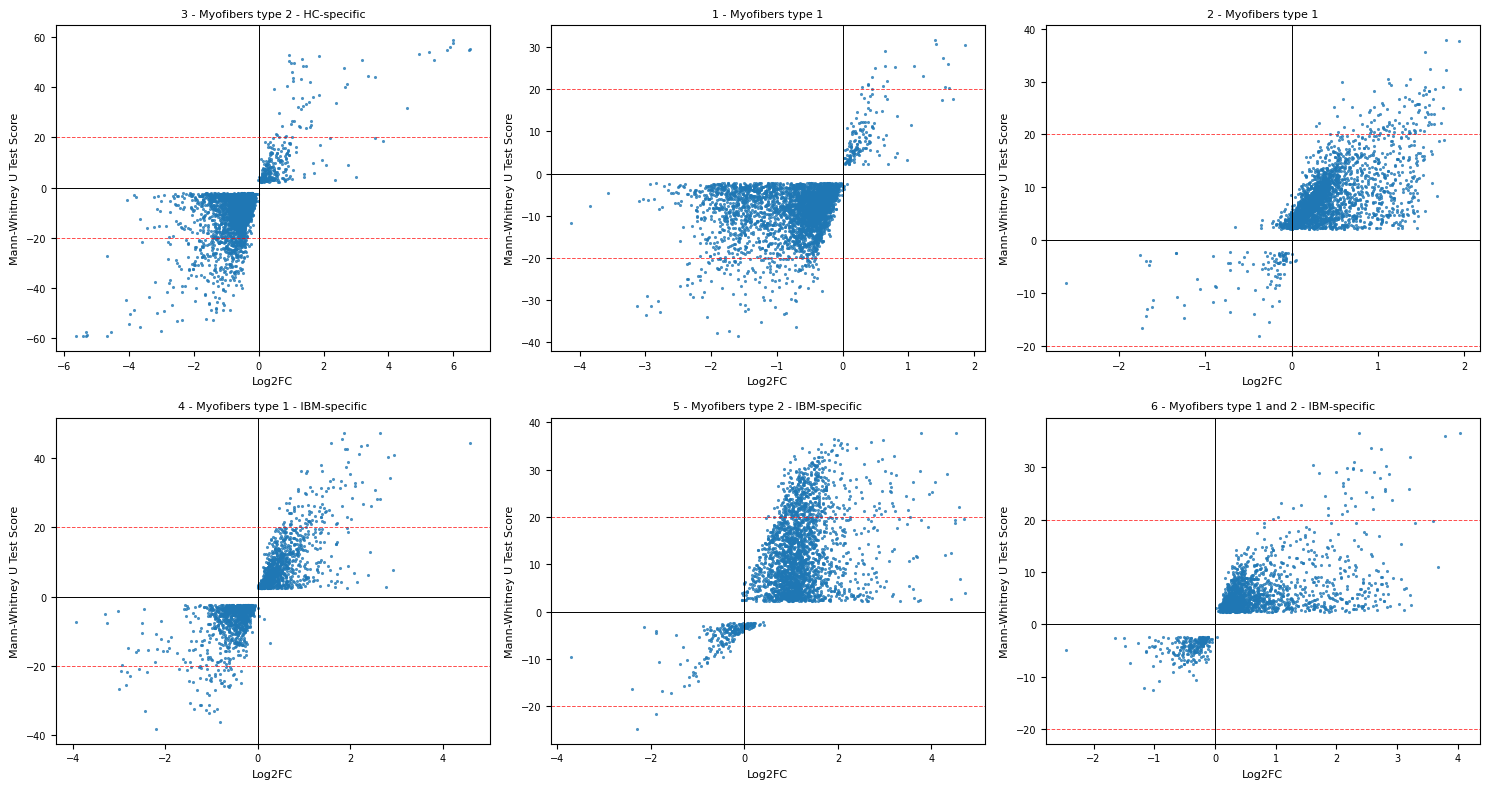

In [ ]:
# Plot mann whitney U score vs Log2FC per niche
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

niches = [
    "3 - Myofibers type 2 - HC-specific",
    "1 - Myofibers type 1",
    "2 - Myofibers type 1",
    "4 - Myofibers type 1 - IBM-specific",
    "5 - Myofibers type 2 - IBM-specific",
    "6 - Myofibers type 1 and 2 - IBM-specific"]

for i, niche in enumerate(niches):
    ax = axes[i]
    d = deg_df[deg_df['group'] == niche]
    
    ax.scatter(
        d['logfoldchanges'], d['scores'],
        s=5, alpha=0.8, linewidths=0,
    )
    
    ax.axvline(0, color='black', linewidth=0.7, linestyle='-')
    ax.axhline(20, color='red', linewidth=0.7, linestyle='--', alpha=0.7)
    ax.axhline(-20, color='red', linewidth=0.7, linestyle='--', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='-')
    ax.set_title(niche, fontsize=8)
    ax.set_xlabel('Log2FC', fontsize=8)
    ax.set_ylabel('Mann-Whitney U Test Score', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('../../output/spatial_niches/DEGs_fiber_niches_integrated.svg')
plt.show()

In [ ]:
# Save csv file with abs(score) >20 and abs(LFC)>1 to select top 10 genes per niche
deg_df_filtered = deg_df[
    (deg_df['scores'].abs() > 20) & 
    (deg_df['logfoldchanges'].abs() > 1)
][['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']].rename(columns={
    'names': 'gene',
    'scores': 'score',
    'logfoldchanges': 'logfoldchange',
    'pvals': 'pval',
    'pvals_adj': 'pval_adj'
})

print(deg_df_filtered.shape)
deg_df_filtered.to_csv("../../output/spatial_niches/spatial_fiber_niches_degs.csv", sep=';')

(1005, 6)


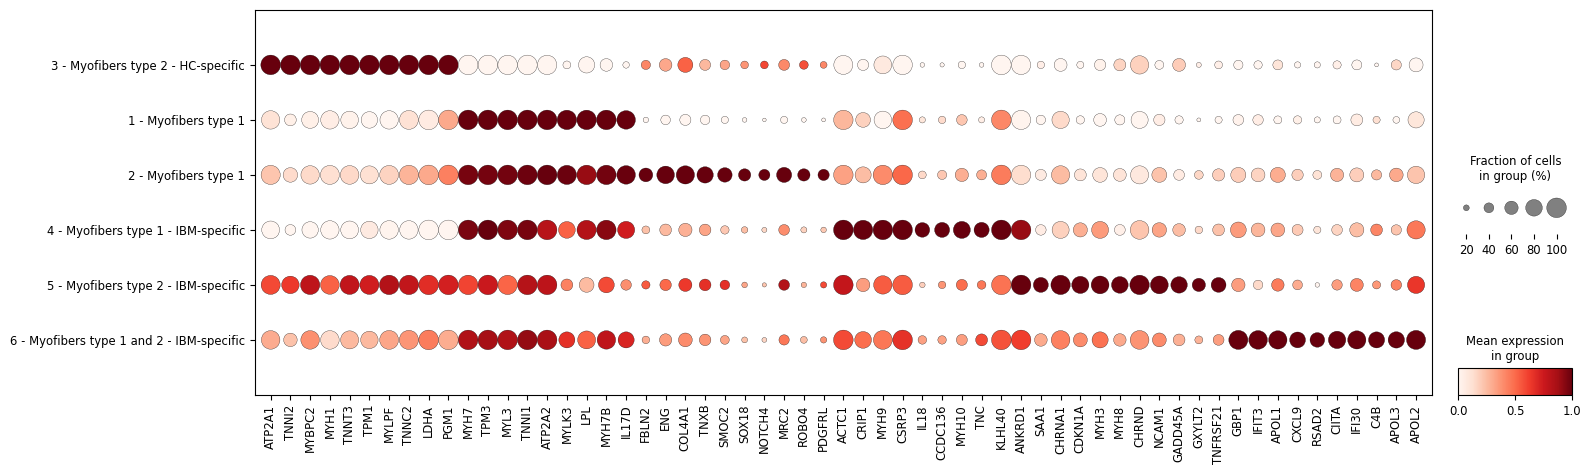

In [ ]:
# Plot top 10 DEGs per niche (highest LFC with wilcoxon score > 20 (without duplicates))
genes_top10 = [
    "ATP2A1", "TNNI2", "MYBPC2", "MYH1", "TNNT3", "TPM1", "MYLPF", "TNNC2", "LDHA", "PGM1",
    "MYH7", "TPM3", "MYL3", "TNNI1", "ATP2A2", "MYLK3", "LPL", "MYH7B", "IL17D",
    "FBLN2", "ENG", "COL4A1", "TNXB", "SMOC2", "SOX18", "NOTCH4", "MRC2", "ROBO4", "PDGFRL", 
    "ACTC1", "CRIP1", "MYH9", "CSRP3", "IL18", "CCDC136", "MYH10", "TNC", "KLHL40", "ANKRD1",
    "SAA1", "CHRNA1", "CDKN1A", "MYH3", "MYH8", "CHRND", "NCAM1", "GADD45A", "GXYLT2", "TNFRSF21", 
    "GBP1", "IFIT3", "APOL1", "CXCL9", "RSAD2", "CIITA", "IFI30", "C4B", "APOL3", "APOL2"
]

niche_order = [
    "3 - Myofibers type 2 - HC-specific",
    "1 - Myofibers type 1",
    "2 - Myofibers type 1",
    "4 - Myofibers type 1 - IBM-specific",
    "5 - Myofibers type 2 - IBM-specific",
    "6 - Myofibers type 1 and 2 - IBM-specific"]

adata.obs['spatial_niches_fibers'] = pd.Categorical(
    adata.obs['spatial_niches_fibers'],
    categories=niche_order,
    ordered=True
)

sc.pl.dotplot(
    adata,
    var_names=genes_top10,
    groupby="spatial_niches_fibers",
    standard_scale="var",
    layer="size_normalized_log",
    figsize=(17, 5),
    save="doplot_fiber_niches_integrated.svg"
)

### Expression of aggregation-prone transcripts 

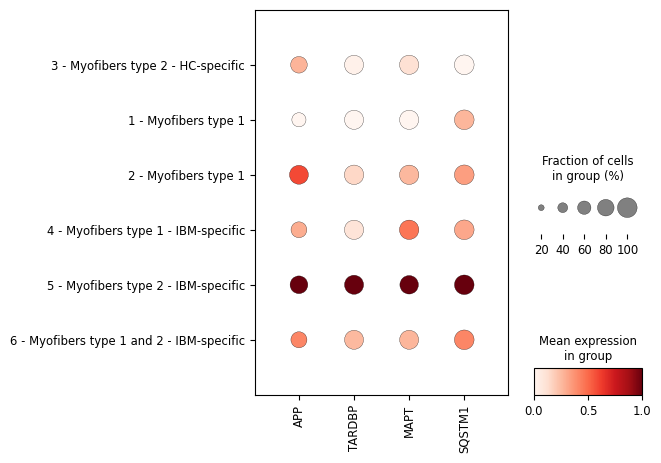

In [6]:
genes = ["APP", "TARDBP","MAPT","SQSTM1"]

niche_order = [
    "3 - Myofibers type 2 - HC-specific",
    "1 - Myofibers type 1",
    "2 - Myofibers type 1",
    "4 - Myofibers type 1 - IBM-specific",
    "5 - Myofibers type 2 - IBM-specific",
    "6 - Myofibers type 1 and 2 - IBM-specific"]

adata.obs['spatial_niches_fibers'] = pd.Categorical(
    adata.obs['spatial_niches_fibers'],
    categories=niche_order,
    ordered=True
)

sc.pl.dotplot(
    adata,
    var_names=genes,
    groupby="spatial_niches_fibers",
    standard_scale="var",
    layer="size_normalized_log",
    figsize=(5, 5),
    save="doplot_fiber_niches_aggregation_transcripts.svg"
)

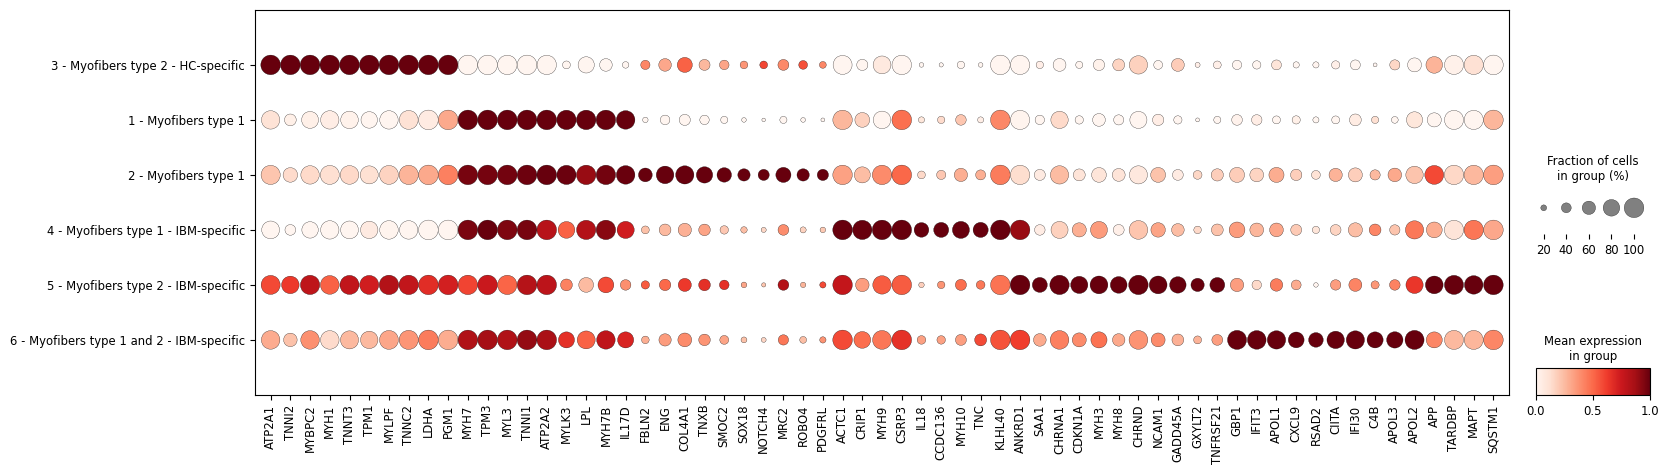

In [ ]:
genes_top10 = [
    "ATP2A1", "TNNI2", "MYBPC2", "MYH1", "TNNT3", "TPM1", "MYLPF", "TNNC2", "LDHA", "PGM1",
    "MYH7", "TPM3", "MYL3", "TNNI1", "ATP2A2", "MYLK3", "LPL", "MYH7B", "IL17D",
    "FBLN2", "ENG", "COL4A1", "TNXB", "SMOC2", "SOX18", "NOTCH4", "MRC2", "ROBO4", "PDGFRL", 
    "ACTC1", "CRIP1", "MYH9", "CSRP3", "IL18", "CCDC136", "MYH10", "TNC", "KLHL40", "ANKRD1",
    "SAA1", "CHRNA1", "CDKN1A", "MYH3", "MYH8", "CHRND", "NCAM1", "GADD45A", "GXYLT2", "TNFRSF21", 
    "GBP1", "IFIT3", "APOL1", "CXCL9", "RSAD2", "CIITA", "IFI30", "C4B", "APOL3", "APOL2",
    "APP", "TARDBP","MAPT","SQSTM1"] # add aggregation transcripts

niche_order = [
    "3 - Myofibers type 2 - HC-specific",
    "1 - Myofibers type 1",
    "2 - Myofibers type 1",
    "4 - Myofibers type 1 - IBM-specific",
    "5 - Myofibers type 2 - IBM-specific",
    "6 - Myofibers type 1 and 2 - IBM-specific"]

adata.obs['spatial_niches_fibers'] = pd.Categorical(
    adata.obs['spatial_niches_fibers'],
    categories=niche_order,
    ordered=True
)

sc.pl.dotplot(
    adata,
    var_names=genes_top10,
    groupby="spatial_niches_fibers",
    standard_scale="var",
    layer="size_normalized_log",
    figsize=(18, 5),
    save="doplot_fiber_niches_integrated_with_aggregation_transcripts.svg"
)

### Expression of aggregation-prone transcripts per fiber type in spatial niche 5 and 6

In [6]:
adata

View of AnnData object with n_obs × n_vars = 8964 × 5850
    obs: 'cell_ID', 'fov_labels', 'sample_id', 'condition', 'muscle_type', 'sample_id_new', 'cell_type_annotation', 'cell_type_annotation_clean', 'sample_condition', 'unique_cell_ID_5000', 'spatial_niches', 'spatial_niches_number', 'spatial_niches_fibers', 'spatial_niches_fibers_number', 'unique_cell_ID_480', 'cell_type_annotation_fiber_subtypes', 'CD8_in_neighborhood_200_480', 'CD8_in_neighborhood_200_5000', 'CD8_in_neighborhood_200_mean', 'shape_size_5000', 'shape_size_480', 'shape_size_mean', 'CD4_in_neighborhood_200_480', 'CD4_in_neighborhood_200_5000', 'CD4_in_neighborhood_200_mean', 'B_cells_in_neighborhood_200_480', 'B_cells_in_neighborhood_200_5000', 'B_cells_in_neighborhood_200_mean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'm

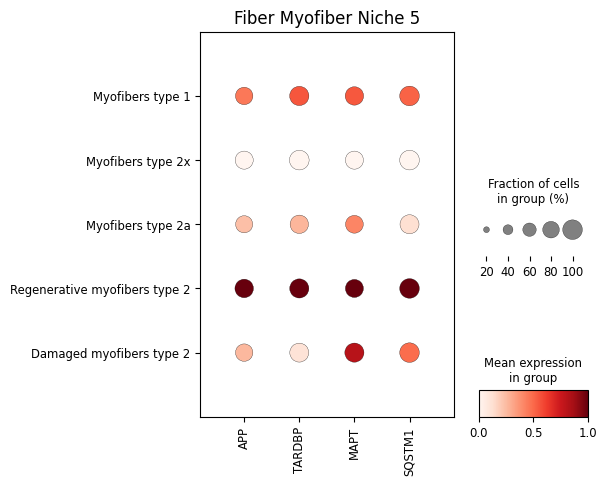

In [29]:
adata_n5 = adata[adata.obs['spatial_niches_fibers_number'] == '5'].copy()

genes = ["APP", "TARDBP","MAPT","SQSTM1"]

sc.pl.dotplot(
    adata_n5,
    var_names=genes,
    groupby="cell_type_annotation_fiber_subtypes",
    standard_scale="var",
    layer="size_normalized_log",
    figsize=(5, 5),
    title='Fiber Myofiber Niche 5',
    save='aggregation_transcripts_per_fibertype_n5.pdf'
)

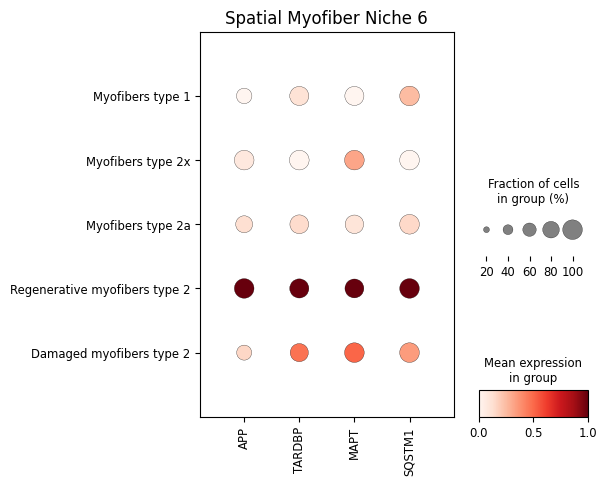

In [28]:
adata_n6 = adata[adata.obs['spatial_niches_fibers_number'] == '6'].copy()

genes = ["APP", "TARDBP","MAPT","SQSTM1"]

sc.pl.dotplot(
    adata_n6,
    var_names=genes,
    groupby="cell_type_annotation_fiber_subtypes",
    standard_scale="var",
    layer="size_normalized_log",
    figsize=(5, 5),
    title='Spatial Myofiber Niche 6',
    save='aggregation_transcripts_per_fibertype_n6.pdf'
)

In [33]:
niche_colors = dict(zip(
    adata.obs['spatial_niches_fibers_number'].cat.categories,
    adata.uns['spatial_niches_fibers_colors']
))

In [34]:
niche_colors

{'1': '#1f77b4',
 '2': '#ff7f0e',
 '3': '#2ca02c',
 '4': '#d62728',
 '5': '#9467bd',
 '6': '#8c564b'}

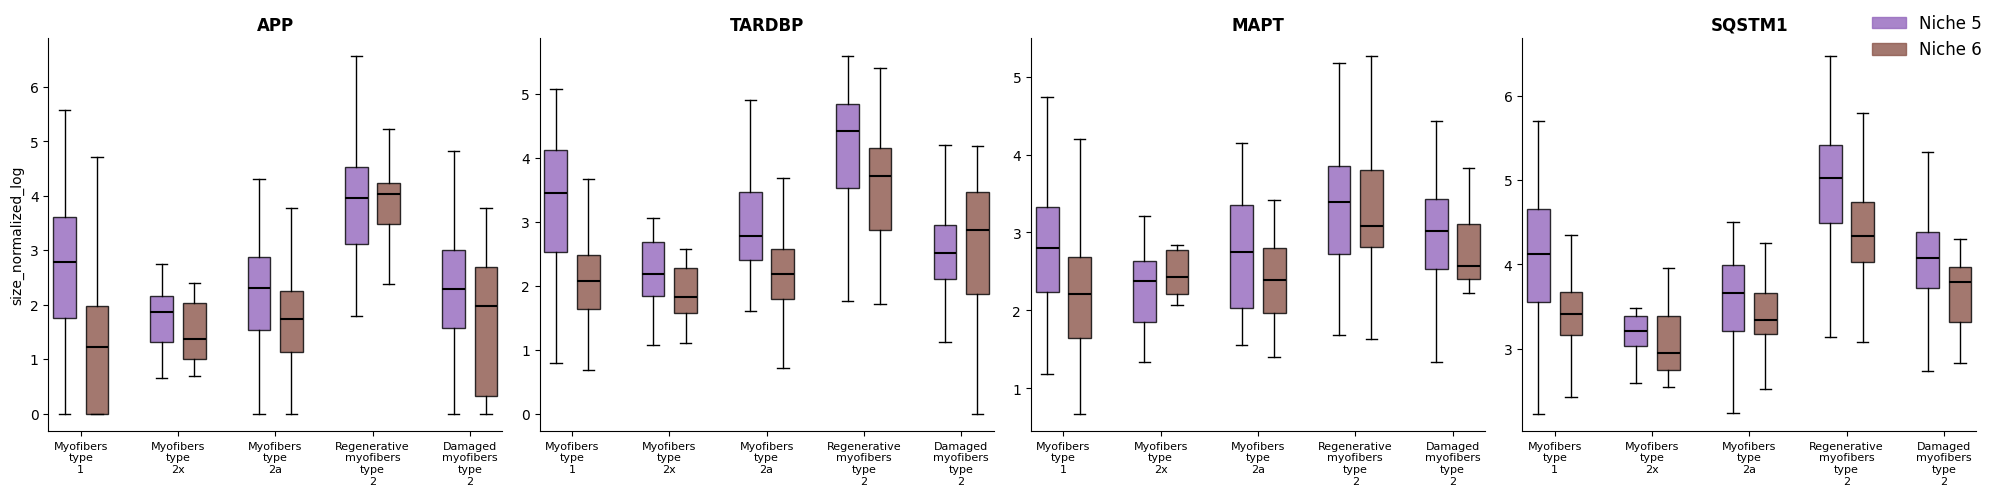

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

genes = ["APP", "TARDBP", "MAPT", "SQSTM1"]
subtypes = ['Myofibers type 1', 'Myofibers type 2x', 'Myofibers type 2a',
            'Regenerative myofibers type 2', 'Damaged myofibers type 2']
niche_colors = {'Niche 5': '#9467bd', 'Niche 6': '#8c564b'}

# Extract aggregation transcripts expression data for both niches
def extract_data(adata, niche_label):
    df = pd.DataFrame(
        adata[:, genes].layers["size_normalized_log"].toarray(), 
        columns=genes,
        index=adata.obs.index
    )
    df['subtype'] = adata.obs['cell_type_annotation_fiber_subtypes'].values
    df['niche'] = niche_label
    return df

df_n5 = extract_data(adata_n5, 'Niche 5')
df_n6 = extract_data(adata_n6, 'Niche 6')
df = pd.concat([df_n5, df_n6])

# Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

for ax, gene in zip(axes, genes):
    positions = []
    box_data = []
    colors = []
    tick_positions = []
    tick_labels = []

    for i, subtype in enumerate(subtypes):
        base = i * 3  # spacing between subtype groups
        for j, (niche, color) in enumerate(niche_colors.items()):
            pos = base + j
            vals = df[(df['subtype'] == subtype) & (df['niche'] == niche)][gene].dropna().values
            positions.append(pos)
            box_data.append(vals)
            colors.append(color)
        tick_positions.append(base + 0.5)
        tick_labels.append(subtype.replace(' ', '\n'))

    bp = ax.boxplot(box_data, positions=positions, widths=0.7,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=1.5))

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_title(gene, fontsize=12, fontweight='bold')
    ax.set_ylabel('size_normalized_log' if gene == genes[0] else '')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend
handles = [mpatches.Patch(color=c, alpha=0.8, label=n) for n, c in niche_colors.items()]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig("../../output/spatial_niches/aggregation_transcripts_per_fibertype_n5_and_n6.pdf")
plt.show()